# Task 9 — Feature Engineering
## Step 5: Creating Derived Features

**Goal:** Create new meaningful features from existing ones that can
give the model additional predictive signal not present in the raw columns.

| New Feature | Derived From | Logic |
|-------------|-------------|-------|
| `FamilySize` | `SibSp + Parch + 1` | Total family members aboard including self |
| `IsAlone` | `FamilySize == 1` | 1 if travelling alone, 0 otherwise |
| `AgeGroup` | `Age` (original) | Binned into Child / Teen / Adult / Senior |
| `FareBin` | `Fare` (original) | Binned into Low / Medium / High / Very High |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Load scaled data and also raw for binning Age/Fare on original values
df = pd.read_csv('../data/cleaned_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1309, 8)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


### 5.1 FamilySize & IsAlone

FamilySize distribution:
 FamilySize
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: count, dtype: int64
Total Alone: 790


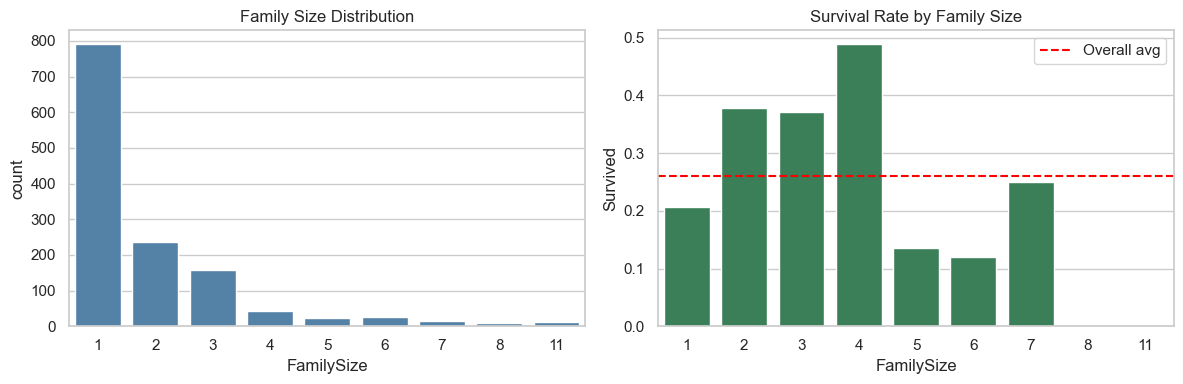

In [3]:
# 1. Create the features
df['FamilySize'] = df['sibsp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 2. Print quick stats
print("FamilySize distribution:\n", df['FamilySize'].value_counts().sort_index())
print(f"Total Alone: {df['IsAlone'].sum()}")

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Plot: Distribution (Seaborn's countplot does the counting for you)
sns.countplot(data=df, x='FamilySize', color='steelblue', ax=axes[0])
axes[0].set_title('Family Size Distribution')

# Right Plot: Survival Rate (Seaborn's barplot automatically calculates the mean)
sns.barplot(data=df, x='FamilySize', y='Survived', color='seagreen', ax=axes[1], errorbar=None)
axes[1].axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall avg')
axes[1].set_title('Survival Rate by Family Size')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.2 AgeGroup — Binning Age into Categories

Using original (pre-scaled) Age values for meaningful bin boundaries.

AgeGroup distribution:
 AgeGroup
Child       94
Teen        99
Adult     1083
Senior      33
Name: count, dtype: int64


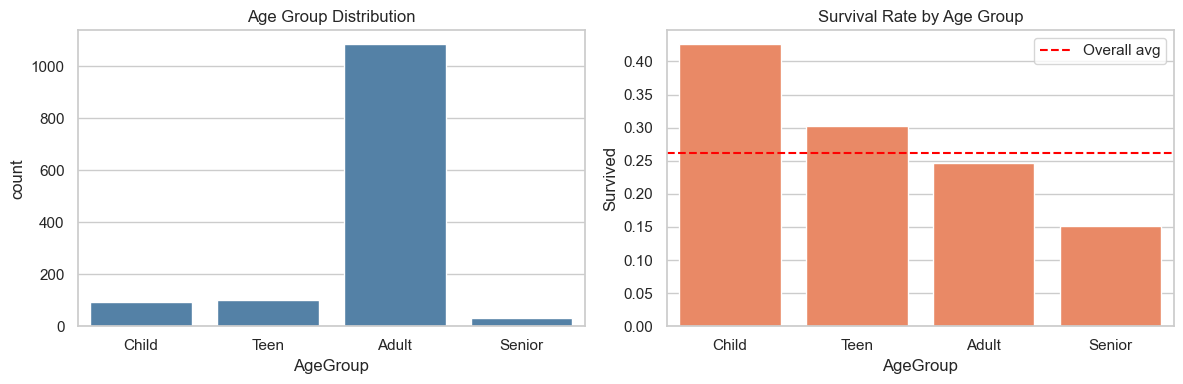


AgeGroup successfully encoded and text column dropped.


In [4]:
# 1. Create the binned feature 
# (Note: Using df['Age'] here. If you specifically need to pull from a separate 'raw' dataframe, just swap it back to raw['Age'])
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 2. Print quick stats (sort=False keeps the natural age order!)
print("AgeGroup distribution:\n", df['AgeGroup'].value_counts(sort=False))

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Distribution
sns.countplot(data=df, x='AgeGroup', color='steelblue', ax=axes[0])
axes[0].set_title('Age Group Distribution')

# Right: Survival Rate (Seaborn automatically calculates the mean of 'Survived' for each group)
sns.barplot(data=df, x='AgeGroup', y='Survived', color='coral', ax=axes[1], errorbar=None)
axes[1].axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall avg')
axes[1].set_title('Survival Rate by Age Group')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Encode as numbers and drop the text column for machine learning
df['AgeGroup_encoded'] = df['AgeGroup'].cat.codes
df.drop(columns=['AgeGroup'], inplace=True)
print("\nAgeGroup successfully encoded and text column dropped.")

### 5.3 FareBin — Binning Fare into Categories

Using original (pre-scaled) Fare values for meaningful bin boundaries.

FareBin distribution:
 FareBin
Low          337
Medium       321
High         328
Very High    323
Name: count, dtype: int64


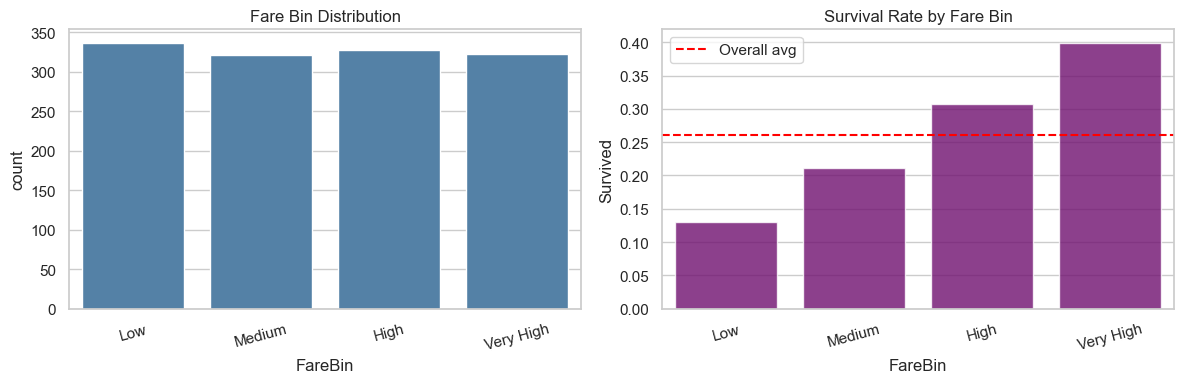


FareBin successfully encoded and text column dropped.


In [5]:
# 1. Create the quantile-binned feature
fare_labels = ['Low', 'Medium', 'High', 'Very High']
df['FareBin'] = pd.qcut(df['Fare'], q=4, labels=fare_labels)

# 2. Print quick stats (sort=False preserves the Low -> Very High order)
print("FareBin distribution:\n", df['FareBin'].value_counts(sort=False))

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Distribution
sns.countplot(data=df, x='FareBin', color='steelblue', ax=axes[0])
axes[0].set_title('Fare Bin Distribution')
axes[0].tick_params(axis='x', rotation=15)

# Right: Survival Rate (Seaborn handles the math behind the scenes)
sns.barplot(data=df, x='FareBin', y='Survived', color='purple', alpha=0.8, ax=axes[1], errorbar=None)
axes[1].axhline(df['Survived'].mean(), color='red', linestyle='--', label='Overall avg')
axes[1].set_title('Survival Rate by Fare Bin')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Encode as numbers and drop the text column for machine learning
df['FareBin_encoded'] = df['FareBin'].cat.codes
df.drop(columns=['FareBin'], inplace=True)
print("\nFareBin successfully encoded and text column dropped.")

### 5.4 Summary of New Features

In [6]:
new_features = ['FamilySize', 'IsAlone', 'AgeGroup_encoded', 'FareBin_encoded']
print(f'New features added: {new_features}')
print(f'Total features: {df.shape[1]}')
df[new_features].head(10)

New features added: ['FamilySize', 'IsAlone', 'AgeGroup_encoded', 'FareBin_encoded']
Total features: 12


,FamilySize,IsAlone,AgeGroup_encoded,FareBin_encoded
0,2,0,2,0
1,2,0,2,3
2,1,1,2,1
3,2,0,2,3
4,1,1,2,1
5,1,1,2,1
6,1,1,2,3
7,5,0,0,2
8,3,0,2,1
9,2,0,1,2


### 5.5 Save Output

In [7]:
df.to_csv('../data/final_dataset.csv', index=False)
print('Saved to data/final_dataset.csv')

Saved to data/final_dataset.csv
